In [52]:
import os, gc
import numpy as np
from PIL import Image, ImageFilter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import timm
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter

In [53]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blank1508/mendeley-lbc-cervical-cancer")

print("Path to dataset files:", path)
root_dir = path

Path to dataset files: /kaggle/input/datasets/blank1508/mendeley-lbc-cervical-cancer


In [54]:
import os
from PIL import Image
from torch.utils.data import Dataset

class CervicalCancerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        self.labels = []

        # Updated class names based on your image
        self.class_names = [
            'High squamous intra-epithelial lesion',
            'Low squamous intra-epithelial lesion',
            'Negative for Intraepithelial malignancy',
            'Squamous cell carcinoma'
        ]
        
        # Create a mapping for folder matching
        self.class_map = {name: i for i, name in enumerate(self.class_names)}
        
        self._load_data()

    def _load_data(self):
        # Iterate through the subdirectories in root_dir
        for folder_name in os.listdir(self.root_dir):
            folder_path = os.path.join(self.root_dir, folder_name)
            
            if not os.path.isdir(folder_path):
                continue

            # Match folder name to our defined class names
            label = None
            for name in self.class_names:
                # We use 'in' to handle potential trailing spaces or slight naming variations
                if name.lower() in folder_name.lower():
                    label = self.class_map[name]
                    break
            
            if label is not None:
                # Walk through to find the images (handling the nested CROPPED structure if present)
                for root, _, files in os.walk(folder_path):
                    for filename in files:
                        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                            self.data.append(os.path.join(root, filename))
                            self.labels.append(label)

        print(f"Loaded {len(self.data)} images across {len(self.class_names)} categories.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [55]:
IMAGENET_MEAN=[0.485,0.456,0.406]
IMAGENET_STD=[0.229,0.224,0.225]

# class RandomStainJitter:
#     def __call__(self, img):
#         # Ensure input is PIL
#         return transforms.ColorJitter(0.3,0.3,0.3,0.05)(img)

# class RandomGaussianBlur:
#     def __call__(self, img):
#         # This only works on PIL Images
#         return img.filter(ImageFilter.GaussianBlur(radius=np.random.uniform(0.1,1.5)))
# RandomStainJitter(),
# RandomGaussianBlur(),
    
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224,scale=(0.6,1.0)),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(), # ToTensor must be AFTER PIL filters
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

test_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

In [56]:
full_dataset = CervicalCancerDataset(root_dir, transform=test_tf)
full_dataset.transform = None
print("Total images:", len(full_dataset))
# print("Classes:", dataset.classes)
num_classes = len(full_dataset.class_names)
print("No of classes : ", num_classes)

Loaded 962 images across 4 categories.
Total images: 962
No of classes :  4


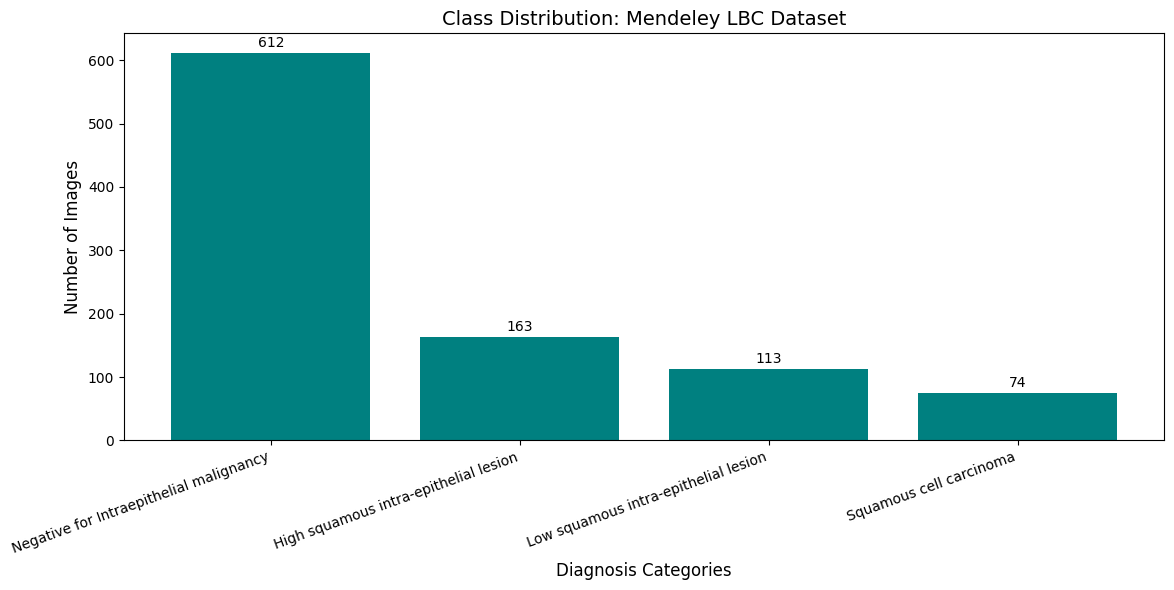

In [57]:
import matplotlib.pyplot as plt
from collections import Counter

# 1. Count the occurrences of each label index
label_counts = Counter(full_dataset.labels)

# 2. Map the counts to the class names in the correct order
# We iterate through range(num_classes) to ensure the order matches class_names
counts = [label_counts[i] for i in range(len(full_dataset.class_names))]
labels = full_dataset.class_names

# 3. Create the plot
plt.figure(figsize=(12, 6))
# Optional: Sort bars by count for better readability
sorted_data = sorted(zip(labels, counts), key=lambda x: x[1], reverse=True)
sorted_labels, sorted_counts = zip(*sorted_data)

bars = plt.bar(sorted_labels, sorted_counts, color='teal')

# Add labels and title
plt.xlabel('Diagnosis Categories', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution: Mendeley LBC Dataset', fontsize=14)
plt.xticks(rotation=20, ha='right')

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [58]:
from torch.utils.data import Subset

# 1. First, create the raw dataset without a fixed transform
full_dataset_raw = CervicalCancerDataset(root_dir=path, transform=None)

# 2. Define Indices (Example Split: 80% Train, 10% Val, 10% Test)
dataset_size = len(full_dataset_raw)
all_labels = np.array(full_dataset_raw.labels)
indices = np.arange(len(all_labels))

# First split: 60% Train, 40% for (Val + Test)
train_idx, temp_idx = train_test_split(
    indices, 
    test_size=0.40, 
    stratify=all_labels, 
    random_state=42
)

# Second split: Split the 20% into half (10% Val, 10% Test)
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.50, 
    stratify=all_labels[temp_idx], 
    random_state=42
)

print(f"Stratified Split Complete:")
print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

# 3. Wrapper Class to apply specific transforms
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index] # Gets PIL Image and Label
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 4. Create the final subset objects
train_dataset = TransformedSubset(Subset(full_dataset_raw, train_idx), transform=train_tf)
val_dataset = TransformedSubset(Subset(full_dataset_raw, val_idx), transform=test_tf)
test_dataset = TransformedSubset(Subset(full_dataset_raw, test_idx), transform=test_tf)

Loaded 962 images across 4 categories.
Stratified Split Complete:
Train: 577 | Val: 192 | Test: 193


In [59]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import numpy as np

# 1. Force recalculation of labels from the ACTUAL indices in the subset
train_indices = train_dataset.subset.indices
train_labels = np.array([full_dataset_raw.labels[i] for i in train_indices])

# 1. Simply use a standard DataLoader without a sampler
# This will load samples in their natural distribution from the dataset
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,       # Standard shuffling instead of weighted sampling
    num_workers=8,      # You can safely keep 8 workers now
    pin_memory=True     # Recommended for faster GPU transfer
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [60]:
# from collections import Counter
# import torch
# import numpy as np

# def print_loader_distribution(loader, dataset_obj, name="DataLoader"):
#     print(f"Analyzing {name} distribution...")
    
#     # 1. If it's a WeightedRandomSampler, we can simulate its choice
#     if hasattr(loader, 'sampler') and hasattr(loader.sampler, 'weights'):
#         # Get the actual labels from the underlying subset
#         # loader.dataset is your TransformedSubset
#         # loader.dataset.subset is the Subset
#         # loader.dataset.subset.indices are the train_idx
#         indices = loader.dataset.subset.indices
#         all_labels = np.array(dataset_obj.labels)[indices]
        
#         # Draw samples based on the sampler's logic
#         # num_samples is 4000 (1000 * 4)
#         sampled_indices = torch.multinomial(
#             loader.sampler.weights, 
#             loader.sampler.num_samples, 
#             replacement=loader.sampler.replacement
#         )
        
#         # Map the sampled relative indices back to actual labels
#         chosen_labels = [all_labels[i] for i in sampled_indices]
#         counts = Counter(chosen_labels)
#         total = len(chosen_labels)
        
#     else:
#         # Fallback for Val/Test loaders (no sampler)
#         indices = loader.dataset.subset.indices
#         chosen_labels = [dataset_obj.labels[i] for i in indices]
#         counts = Counter(chosen_labels)
#         total = len(chosen_labels)

#     print(f"\n--- {name} Distribution ---")
#     for i, class_name in enumerate(dataset_obj.class_names):
#         print(f"{class_name:40}: {counts[i]} samples")
#     print(f"Total samples: {total}\n")

# # Use it
# print_loader_distribution(train_loader, full_dataset_raw, "Balanced Train Loader")

In [61]:
val_sub = TransformedSubset(Subset(full_dataset, val_idx), transform=test_tf)
test_dataset = TransformedSubset(Subset(full_dataset, test_idx), transform=test_tf)


val_loader = DataLoader(val_sub, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 577
Val samples: 192
Test samples: 193


In [62]:
# Check for overlap between sets
set_train = set(train_idx)
set_val = set(val_idx)
set_test = set(test_idx)

overlap_train_test = set_train.intersection(set_test)
overlap_train_val = set_train.intersection(set_val)
overlap_val_test = set_val.intersection(set_test)

print(f"Overlap Train/Test: {len(overlap_train_test)}")
print(f"Overlap Train/Val:  {len(overlap_train_val)}")
print(f"Overlap Val/Test:   {len(overlap_val_test)}")

Overlap Train/Test: 0
Overlap Train/Val:  0
Overlap Val/Test:   0


In [63]:
num_epochs = 60
patience = 30
batch_size = 32
learning_rate = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [64]:
# --- 1. PARALLEL CBAM MODULE ---
class ParallelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(ParallelAttention, self).__init__()

        # Channel Attention Path
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction_ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction_ratio, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

        # Spatial Attention Path
        self.spatial_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):
        # Channel Attention
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        channel_att = self.sigmoid(avg_out + max_out)
        channel_res = x * channel_att

        # Spatial Attention
        avg_mask = torch.mean(x, dim=1, keepdim=True)
        max_mask, _ = torch.max(x, dim=1, keepdim=True)
        spatial_att = self.sigmoid(self.spatial_conv(torch.cat([avg_mask, max_mask], dim=1)))
        spatial_res = x * spatial_att

        # Parallel Fusion (Additive + Identity)
        return x + channel_res + spatial_res

# --- 2. MODEL INTEGRATION ---
class ResNet18ParallelCBAM(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet18ParallelCBAM, self).__init__()
        # Load pre-trained ResNet-18
        self.base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Apply Parallel Attention after Layer 4
        self.attention = ParallelAttention(in_channels=512)

        # Final layers
        self.avgpool = self.base_model.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.base_model.conv1(x)
        x = self.base_model.bn1(x)
        x = self.base_model.relu(x)
        x = self.base_model.maxpool(x)

        x = self.base_model.layer1(x)
        x = self.base_model.layer2(x)
        x = self.base_model.layer3(x)
        x = self.base_model.layer4(x)

        x = self.attention(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# --- 3. CONFIGURATION & PATHS ---
model_name = "ResNet18ParallelCBAM"

# Updated Path Names
path_acc = f'best_{model_name}_acc.pth'
path_loss = f'best_{model_name}_loss.pth'

# --- 5. INITIALIZATION ---
model = ResNet18ParallelCBAM(num_classes=num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
criterion = nn.CrossEntropyLoss()

# --- 6. TRAINING LOOP ---
best_val_loss = float('inf')
best_val_acc = 0.0
early_stop_counter = 0
history3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Starting training for {model_name} on {device}...")

for epoch in range(num_epochs):
    # TRAINING PHASE
    model.train()
    train_loss, train_correct = 0.0, 0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    scheduler.step()

    # VALIDATION PHASE
    model.eval()
    val_loss, val_correct = 0.0, 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    num_train_samples = train_loader.sampler.num_samples if hasattr(train_loader, 'sampler') else len(train_idx)
    num_val_samples = len(val_idx)

    metrics = {
        'train_loss': train_loss / num_train_samples,
        'train_acc': train_correct / num_train_samples,
        'val_loss': val_loss / num_val_samples,
        'val_acc': val_correct / num_val_samples
    }

    # Append to history1
    for key in history3: 
        history3[key].append(metrics[key])
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"TR_Loss: {metrics['train_loss']:.4f} | TR_Acc: {metrics['train_acc']:.4f} | "
          f"VAL_Loss: {metrics['val_loss']:.4f} | VAL_Acc: {metrics['val_acc']:.4f}")
    # --- UPDATED CHECKPOINTING ---
    if metrics['val_acc'] > best_val_acc:
        best_val_acc = metrics['val_acc']
        torch.save(model.state_dict(), path_acc)
        print(f"--> Saved Best Accuracy: {path_acc}")

    if metrics['val_loss'] < best_val_loss:
        best_val_loss = metrics['val_loss']
        torch.save(model.state_dict(), path_loss)
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nTraining Complete. Best Accuracy: {best_val_acc:.4f}")

Starting training for ResNet18ParallelCBAM on cuda...


Epoch 1/60 [Train]: 100%|██████████| 19/19 [00:14<00:00,  1.29it/s, loss=3.2075]


Epoch [1/60] TR_Loss: 0.4693 | TR_Acc: 0.8059 | VAL_Loss: 0.1111 | VAL_Acc: 0.9531
--> Saved Best Accuracy: best_ResNet18ParallelCBAM_acc.pth


Epoch 2/60 [Train]: 100%|██████████| 19/19 [00:14<00:00,  1.31it/s, loss=3.0306]


Epoch [2/60] TR_Loss: 0.1202 | TR_Acc: 0.9515 | VAL_Loss: 0.0530 | VAL_Acc: 0.9740
--> Saved Best Accuracy: best_ResNet18ParallelCBAM_acc.pth


...

Epoch [47/60] TR_Loss: 0.0085 | TR_Acc: 0.9983 | VAL_Loss: 0.0495 | VAL_Acc: 0.9844


Epoch 48/60 [Train]: 100%|██████████| 19/19 [00:15<00:00,  1.21it/s, loss=1.4964]


Epoch [48/60] TR_Loss: 0.0039 | TR_Acc: 0.9983 | VAL_Loss: 0.0380 | VAL_Acc: 0.9844


Epoch 49/60 [Train]: 100%|██████████| 19/19 [00:15<00:00,  1.22it/s, loss=0.1179]
                                                                

Epoch [49/60] TR_Loss: 0.0132 | TR_Acc: 0.9965 | VAL_Loss: 0.0346 | VAL_Acc: 0.9896
Early stopping at epoch 49

Training Complete. Best Accuracy: 0.9948


In [65]:
# ===================== SWIN TINY COMPLETE TRAINING CELL =====================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

# -------------------- 1. MODEL DEFINITION --------------------
class SwinTinyClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(SwinTinyClassifier, self).__init__()

        # Load pretrained Swin-Tiny
        self.base_model = models.swin_t(
            weights=models.Swin_T_Weights.DEFAULT
        )

        # Replace classification head
        in_features = self.base_model.head.in_features
        self.base_model.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)


# -------------------- 2. CONFIGURATION --------------------
model_name = "SwinTiny"

path_acc = f'best_{model_name}_acc.pth'
path_loss = f'best_{model_name}_loss.pth'


# -------------------- 3. INITIALIZATION --------------------
model = SwinTinyClassifier(num_classes=num_classes).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-2
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

criterion = nn.CrossEntropyLoss()


# -------------------- 4. TRAINING LOOP --------------------
best_val_loss = float('inf')
best_val_acc = 0.0
early_stop_counter = 0

history_swin = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"Starting training for {model_name} on {device}...")

for epoch in range(num_epochs):

    # -------- TRAIN --------
    model.train()
    train_loss, train_correct = 0.0, 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    scheduler.step()

    # -------- VALIDATION --------
    model.eval()
    val_loss, val_correct = 0.0, 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    num_train_samples = train_loader.sampler.num_samples if hasattr(train_loader, 'sampler') else len(train_idx)
    num_val_samples = len(val_idx)

    train_epoch_loss = train_loss / num_train_samples
    train_epoch_acc = train_correct / num_train_samples
    val_epoch_loss = val_loss / num_val_samples
    val_epoch_acc = val_correct / num_val_samples

    history_swin['train_loss'].append(train_epoch_loss)
    history_swin['train_acc'].append(train_epoch_acc)
    history_swin['val_loss'].append(val_epoch_loss)
    history_swin['val_acc'].append(val_epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"TR_Loss: {train_epoch_loss:.4f} | "
          f"TR_Acc: {train_epoch_acc:.4f} | "
          f"VAL_Loss: {val_epoch_loss:.4f} | "
          f"VAL_Acc: {val_epoch_acc:.4f}")

    # -------- CHECKPOINTING --------
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        torch.save(model.state_dict(), path_acc)
        print(f"--> Saved Best Accuracy: {path_acc}")

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), path_loss)
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nTraining Complete. Best Validation Accuracy: {best_val_acc:.4f}")

Starting training for SwinTiny on cuda...


Epoch 1/60 [Train]: 100%|██████████| 19/19 [00:15<00:00,  1.19it/s, loss=0.0005]


Epoch [1/60] TR_Loss: 0.6359 | TR_Acc: 0.7452 | VAL_Loss: 0.2802 | VAL_Acc: 0.9115
--> Saved Best Accuracy: best_SwinTiny_acc.pth


Epoch 2/60 [Train]: 100%|██████████| 19/19 [00:15<00:00,  1.22it/s, loss=0.0000]


Epoch [2/60] TR_Loss: 0.1928 | TR_Acc: 0.9255 | VAL_Loss: 0.0524 | VAL_Acc: 0.9896
--> Saved Best Accuracy: best_SwinTiny_acc.pth


...

Epoch [58/60] TR_Loss: 0.0033 | TR_Acc: 0.9983 | VAL_Loss: 0.0003 | VAL_Acc: 1.0000


Epoch 59/60 [Train]: 100%|██████████| 19/19 [00:15<00:00,  1.25it/s, loss=0.0000]


Epoch [59/60] TR_Loss: 0.0010 | TR_Acc: 1.0000 | VAL_Loss: 0.0003 | VAL_Acc: 1.0000


Epoch 60/60 [Train]: 100%|██████████| 19/19 [00:15<00:00,  1.24it/s, loss=0.0151]
                                                                

Epoch [60/60] TR_Loss: 0.0003 | TR_Acc: 1.0000 | VAL_Loss: 0.0003 | VAL_Acc: 1.0000

Training Complete. Best Validation Accuracy: 1.0000


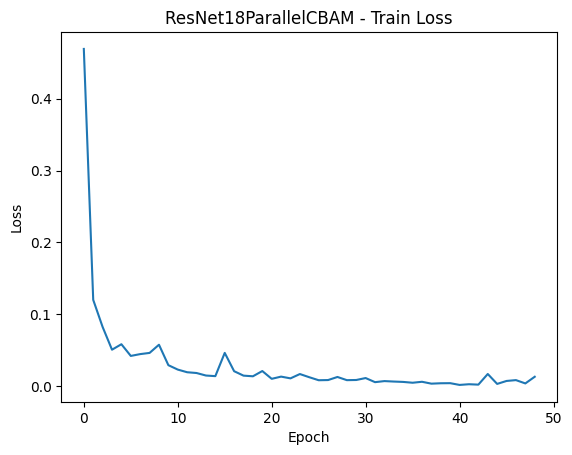

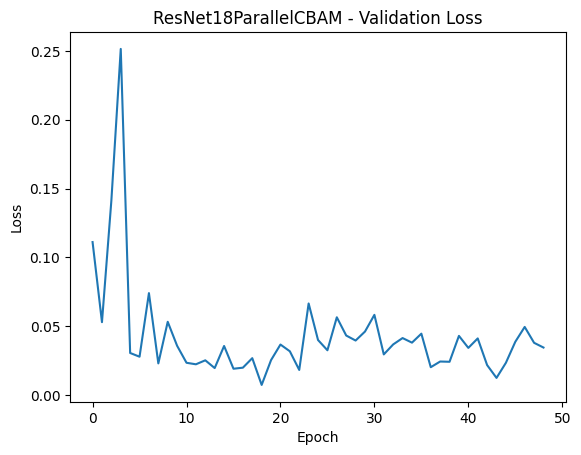

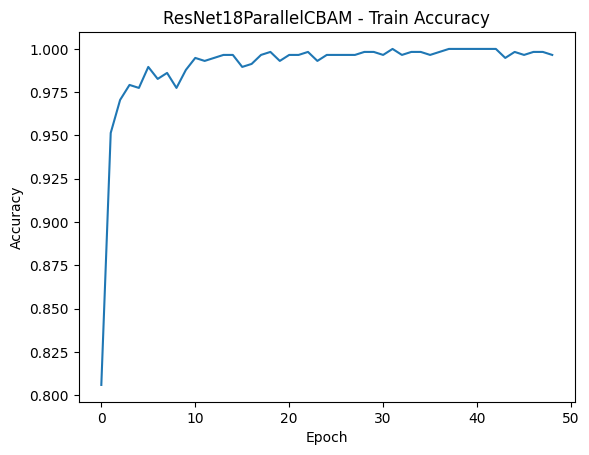

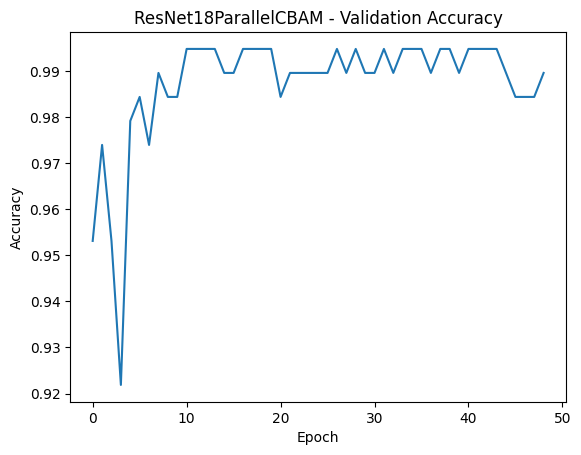

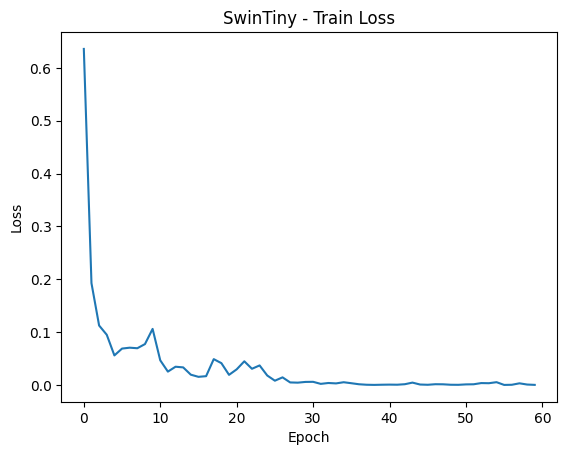

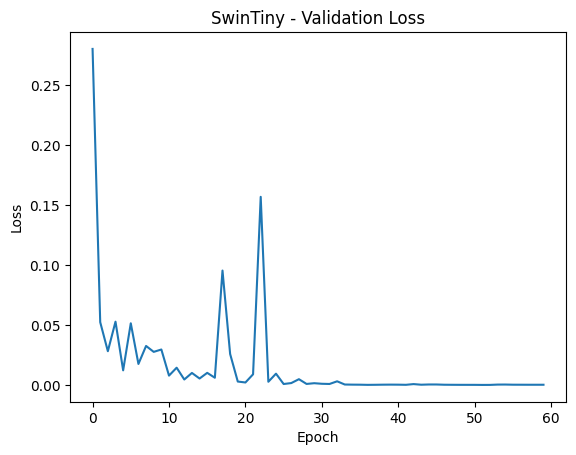

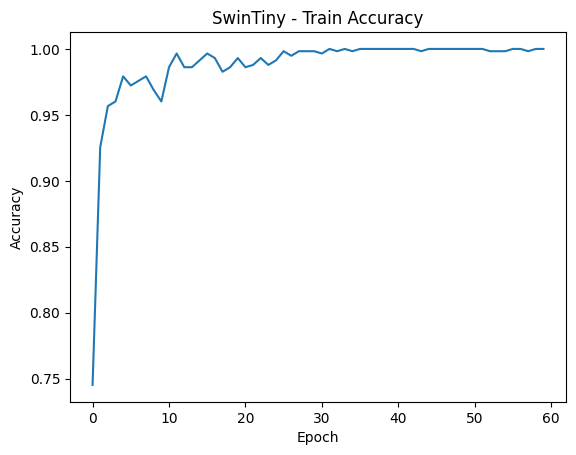

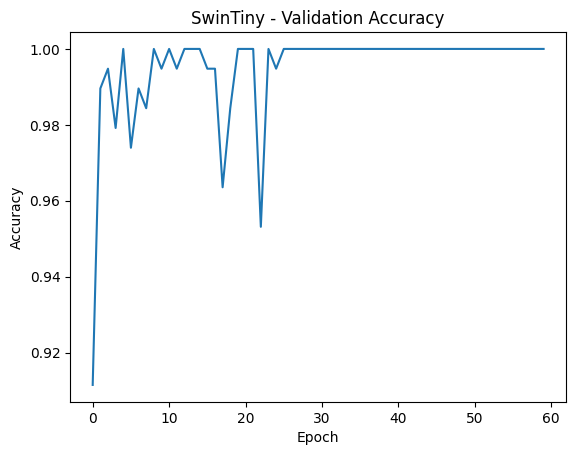

In [66]:
# ===================== PLOT history3 (ResNet18ParallelCBAM) =====================
import matplotlib.pyplot as plt

# 1. Train Loss
plt.figure()
plt.plot(history3['train_loss'])
plt.title("ResNet18ParallelCBAM - Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 2. Validation Loss
plt.figure()
plt.plot(history3['val_loss'])
plt.title("ResNet18ParallelCBAM - Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 3. Train Accuracy
plt.figure()
plt.plot(history3['train_acc'])
plt.title("ResNet18ParallelCBAM - Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 4. Validation Accuracy
plt.figure()
plt.plot(history3['val_acc'])
plt.title("ResNet18ParallelCBAM - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


# ===================== PLOT history_swin (SwinTiny) =====================

# 5. Train Loss
plt.figure()
plt.plot(history_swin['train_loss'])
plt.title("SwinTiny - Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 6. Validation Loss
plt.figure()
plt.plot(history_swin['val_loss'])
plt.title("SwinTiny - Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 7. Train Accuracy
plt.figure()
plt.plot(history_swin['train_acc'])
plt.title("SwinTiny - Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 8. Validation Accuracy
plt.figure()
plt.plot(history_swin['val_acc'])
plt.title("SwinTiny - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


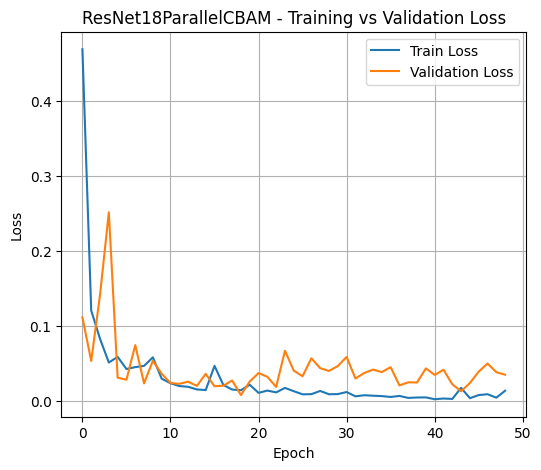

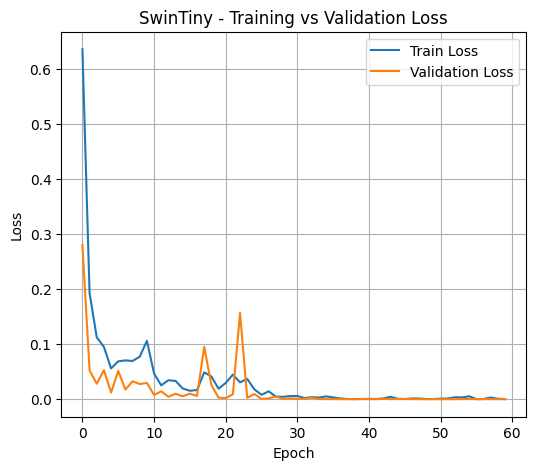

In [79]:
import matplotlib.pyplot as plt

# ===================== CNN LOSS PLOT =====================
plt.figure(figsize=(6,5))

plt.plot(history3['train_loss'], label='Train Loss')
plt.plot(history3['val_loss'], label='Validation Loss')

plt.title("ResNet18ParallelCBAM - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("cnn_loss_curve.jpg", dpi=300, bbox_inches="tight")

plt.show()


# ===================== SWIN LOSS PLOT =====================
plt.figure(figsize=(6,5))

plt.plot(history_swin['train_loss'], label='Train Loss')
plt.plot(history_swin['val_loss'], label='Validation Loss')

plt.title("SwinTiny - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("swin_loss_curve.jpg", dpi=300, bbox_inches="tight")

plt.show()

In [80]:
from IPython.display import FileLink, display

display(FileLink("cnn_loss_curve.jpg"))
display(FileLink("swin_loss_curve.jpg"))

/kaggle/working/cnn_loss_curve.jpg

/kaggle/working/swin_loss_curve.jpg

In [67]:
# ================= ULTRA SUGENO FUSION =================

import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, recall_score, accuracy_score

# -------------------------------------------------------
# 1️⃣ ULTRA-PRECISION UTILITY FUNCTIONS
# -------------------------------------------------------

def get_clarity_weight_inf(probs):
    """
    Min-Entropy based clarity weight (Alpha = ∞)
    """
    n_classes = probs.shape[-1]
    max_p = torch.max(probs, dim=-1)[0]
    ent_inf = -torch.log2(max_p + 1e-9)
    max_ent = np.log2(n_classes)
    norm_ent = torch.clamp(ent_inf / max_ent, 0.0, 1.0)
    return 1.0 - norm_ent


def compute_sugeno_fusion_99(out_cnn, out_trans, class_metadata):
    """
    Sugeno Max-Min Fusion with Cubic Conflict Penalization
    """
    num_classes = out_cnn.shape[0]
    fused_vector = torch.zeros(num_classes, device=out_cnn.device)

    w_cnn = get_clarity_weight_inf(out_cnn)
    w_trans = get_clarity_weight_inf(out_trans)

    for c in range(num_classes):

        # Cubic conflict penalty
        K_dynamic = torch.pow(torch.abs(out_cnn[c] - out_trans[c]), 1)

        s_cnn = class_metadata[c]['cnn'] * w_cnn * out_cnn[c]
        s_trans = class_metadata[c]['trans'] * w_trans * out_trans[c]

        denom = s_cnn + s_trans + K_dynamic + 1e-9

        mu_cnn = s_cnn / denom
        mu_trans = s_trans / denom
        mu_both = torch.tensor(1.0, device=out_cnn.device)

        scores = torch.stack([out_cnn[c], out_trans[c]])
        sorted_scores, indices = torch.sort(scores)

        mu_high = mu_cnn if indices[1] == 0 else mu_trans

        term1 = torch.min(sorted_scores[0], mu_both)
        term2 = torch.min(sorted_scores[1], mu_high)

        fused_vector[c] = torch.max(term1, term2)

    return fused_vector


# -------------------------------------------------------
# 2️⃣ LOAD MODELS
# -------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 4  # change if needed

cnn_model = ResNet18ParallelCBAM(num_classes=num_classes).to(device)
swin_model = SwinTinyClassifier(num_classes=num_classes).to(device)

cnn_model.load_state_dict(torch.load("best_ResNet18ParallelCBAM_acc.pth", map_location=device))
swin_model.load_state_dict(torch.load("best_SwinTiny_acc.pth", map_location=device))

cnn_model.eval()
swin_model.eval()


# -------------------------------------------------------
# 3️⃣ GET INDIVIDUAL MODEL PERFORMANCE
# -------------------------------------------------------

def get_model_performance(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Evaluating Model"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())

    acc = accuracy_score(all_labels, all_preds)
    per_class_recall = recall_score(all_labels, all_preds, average=None)

    return acc, per_class_recall


cnn_acc, cnn_per_class = get_model_performance(cnn_model, test_loader)
swin_acc, swin_per_class = get_model_performance(swin_model, test_loader)

class_metadata = [
    {'cnn': cnn_per_class[i], 'trans': swin_per_class[i]}
    for i in range(num_classes)
]


# -------------------------------------------------------
# 4️⃣ FINAL FUSION WITH TTA
# -------------------------------------------------------

all_fused_preds = []
all_ground_truth = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Ultra Fusion Inference"):

        images = images.to(device)

        # Horizontal Flip TTA
        images_flipped = torch.flip(images, dims=[3])

        # CNN
        p_cnn = (
            F.softmax(cnn_model(images), dim=1) +
            F.softmax(cnn_model(images_flipped), dim=1)
        ) / 2.0

        # Swin
        p_trans = (
            F.softmax(swin_model(images), dim=1) +
            F.softmax(swin_model(images_flipped), dim=1)
        ) / 2.0

        for i in range(images.size(0)):
            fused_output = compute_sugeno_fusion_99(
                p_cnn[i],
                p_trans[i],
                class_metadata
            )

            all_fused_preds.append(torch.argmax(fused_output).item())
            all_ground_truth.append(labels[i].item())


# -------------------------------------------------------
# 5️⃣ RESULTS
# -------------------------------------------------------

fusion_acc = accuracy_score(all_ground_truth, all_fused_preds)

print("\n" + "="*50)
print(f"ResNet18ParallelCBAM Accuracy : {cnn_acc*100:.2f}%")
print(f"SwinTiny Accuracy              : {swin_acc*100:.2f}%")
print(f"\033[1;32mULTRA FUSION ACCURACY          : {fusion_acc*100:.2f}%\033[0m")
print("="*50)

print(classification_report(
    all_ground_truth,
    all_fused_preds,
    target_names=full_dataset.class_names
))

Ultra Fusion Inference: 100%|██████████| 7/7 [00:06<00:00,  1.13it/s]


ResNet18ParallelCBAM Accuracy : 97.41%
SwinTiny Accuracy              : 99.48%
ULTRA FUSION ACCURACY          : 99.48%
                                         precision    recall  f1-score   support

  High squamous intra-epithelial lesion       0.97      1.00      0.99        33
   Low squamous intra-epithelial lesion       1.00      1.00      1.00        22
Negative for Intraepithelial malignancy       1.00      1.00      1.00       123
                Squamous cell carcinoma       1.00      0.93      0.97        15

                               accuracy                           0.99       193
                              macro avg       0.99      0.98      0.99       193
                           weighted avg       0.99      0.99      0.99       193



In [68]:
from sklearn.metrics import classification_report

print(classification_report(
    all_ground_truth,
    all_fused_preds,
    target_names=full_dataset.class_names,
    digits=4
))

                                         precision    recall  f1-score   support

  High squamous intra-epithelial lesion     0.9706    1.0000    0.9851        33
   Low squamous intra-epithelial lesion     1.0000    1.0000    1.0000        22
Negative for Intraepithelial malignancy     1.0000    1.0000    1.0000       123
                Squamous cell carcinoma     1.0000    0.9333    0.9655        15

                               accuracy                         0.9948       193
                              macro avg     0.9926    0.9833    0.9876       193
                           weighted avg     0.9950    0.9948    0.9948       193




Confusion Matrix:
[[ 33   0   0   0]
 [  0  22   0   0]
 [  0   0 123   0]
 [  1   0   0  14]]


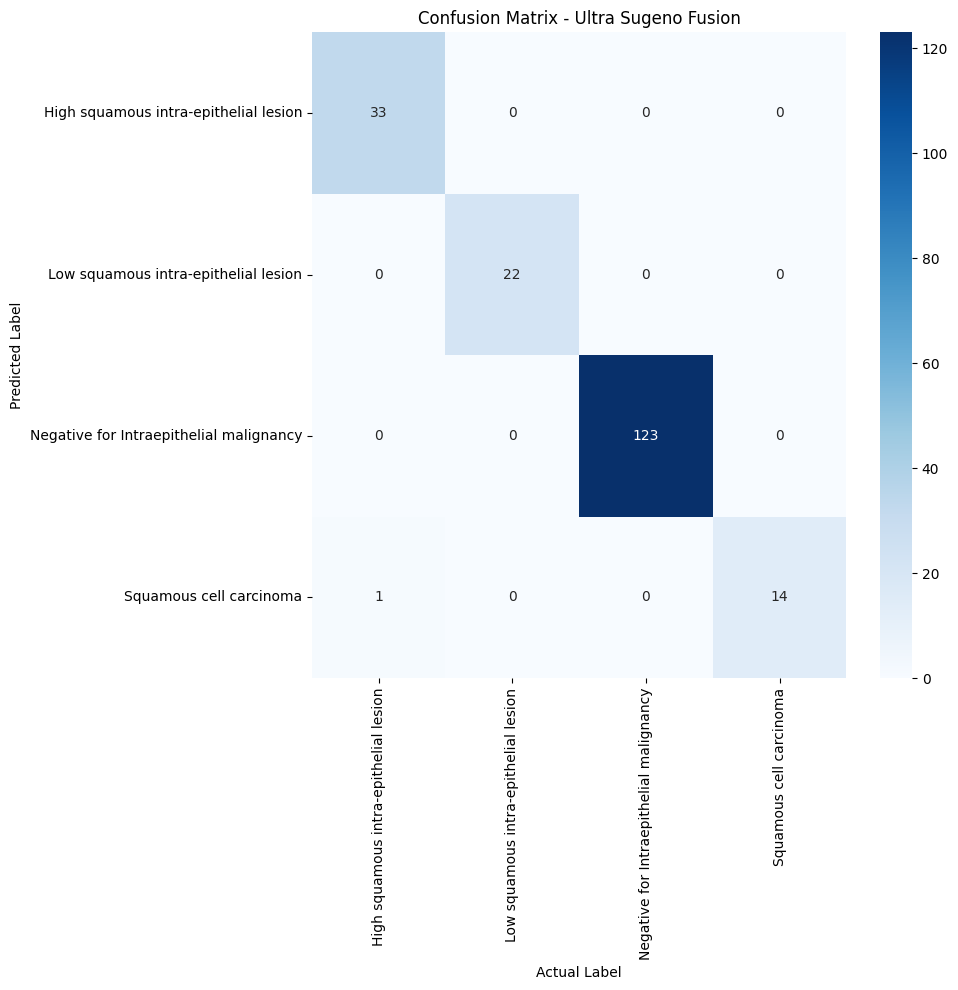

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_ground_truth, all_fused_preds)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(10,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=full_dataset.class_names,
    yticklabels=full_dataset.class_names
)

plt.xlabel("Actual Label")
plt.ylabel("Predicted Label")
plt.title("Confusion Matrix - Ultra Sugeno Fusion")

plt.tight_layout()
plt.show()


Confusion Matrix:
[[ 33   0   0   0]
 [  0  22   0   0]
 [  0   0 123   0]
 [  1   0   0  14]]


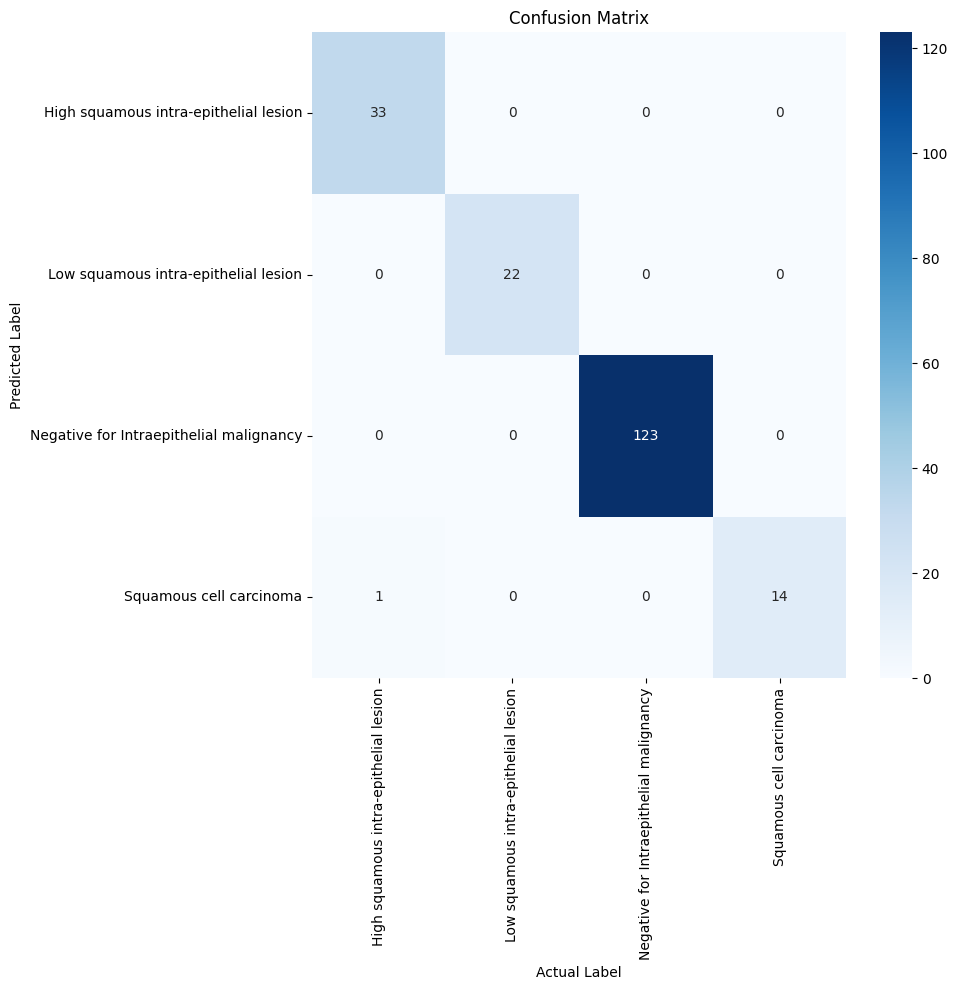

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_ground_truth, all_fused_preds)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(10,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=full_dataset.class_names,
    yticklabels=full_dataset.class_names
)

plt.xlabel("Actual Label")
plt.ylabel("Predicted Label")
plt.title("Confusion Matrix")

plt.tight_layout()

# Save image
plt.savefig("confusion_matrix_fusion.jpg", dpi=300, bbox_inches="tight")

plt.show()

In [71]:
from IPython.display import FileLink
FileLink("confusion_matrix_fusion.jpg")

/kaggle/working/confusion_matrix_fusion.jpg


Confusion Matrix:
[[ 33   0   0   0]
 [  0  22   0   0]
 [  0   0 123   0]
 [  1   0   0  14]]


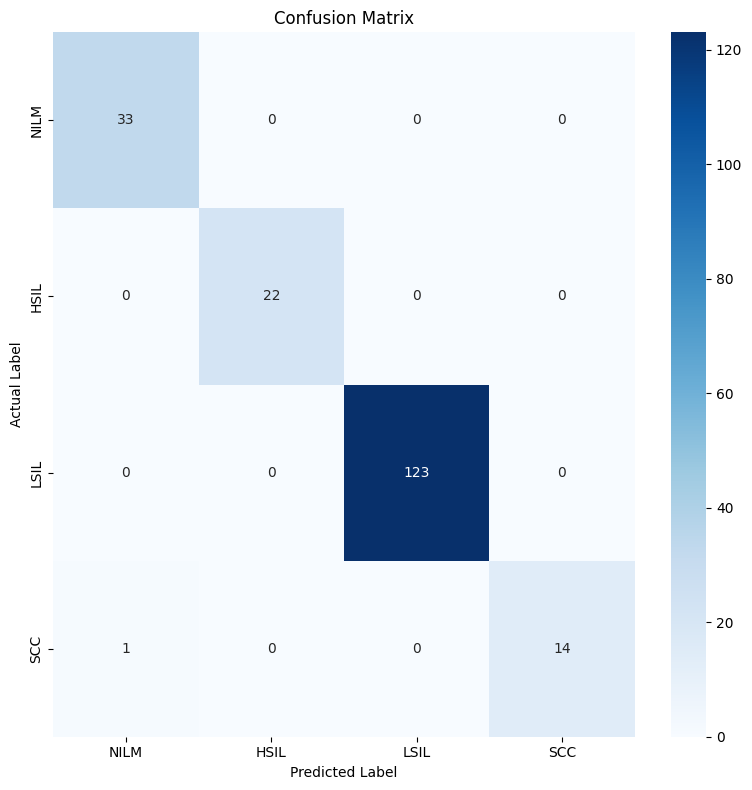

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_ground_truth, all_fused_preds)

print("\nConfusion Matrix:")
print(cm)

# Abbreviated class labels
labels = ["NILM", "HSIL", "LSIL", "SCC"]

plt.figure(figsize=(8,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

# Add abbreviation legend below figure
# plt.figtext(
#     0.5, -0.08,
#     "NILM: Negative for Intra-epithelial Malignancy, "
#     "HSIL: High Squamous Intra-epithelial Lesion, "
#     "LSIL: Low Squamous Intra-epithelial Lesion, "
#     "SCC: Squamous Cell Carcinoma",
#     wrap=True,
#     horizontalalignment="center",
#     fontsize=11
# )

plt.tight_layout()

# Save image
plt.savefig("confusion_matrix_fusion.jpg", dpi=300, bbox_inches="tight")

plt.show()


Confusion Matrix:
[[ 33   0   0   0]
 [  0  22   0   0]
 [  0   0 123   0]
 [  1   0   0  14]]


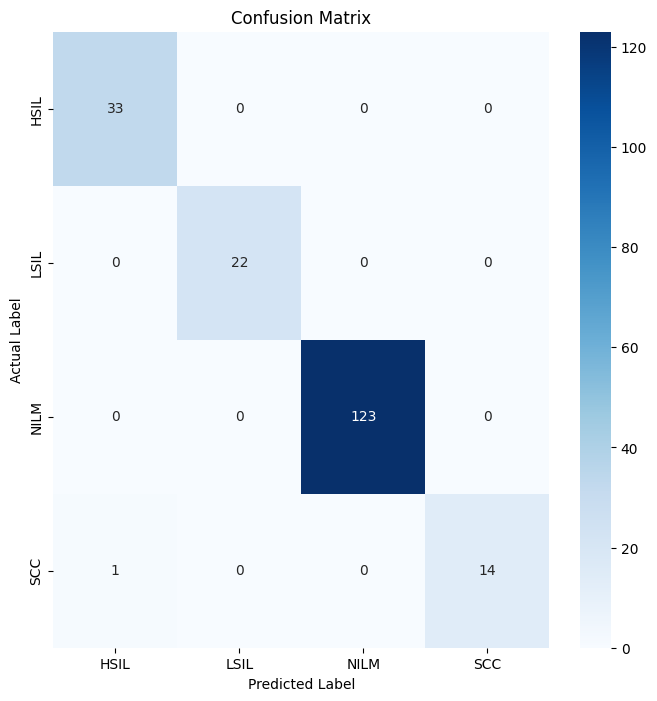

In [73]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_ground_truth, all_fused_preds)

print("\nConfusion Matrix:")
print(cm)

# One-to-one mapping with dataset class order
label_map = {
    "Negative for Intraepithelial malignancy": "NILM",
    "High squamous intra-epithelial lesion": "HSIL",
    "Low squamous intra-epithelial lesion": "LSIL",
    "Squamous cell carcinoma": "SCC"
}

# Convert dataset names to abbreviations in same order
labels = [label_map[name] for name in full_dataset.class_names]

plt.figure(figsize=(8,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

# Index / legend below figure
# legend_text = (
#     "NILM → Negative for Intraepithelial Malignancy\n"
#     "HSIL → High Squamous Intra-epithelial Lesion\n"
#     "LSIL → Low Squamous Intra-epithelial Lesion\n"
#     "SCC → Squamous Cell Carcinoma"
# )

# plt.figtext(
#     0.5, -0.12,
#     legend_text,
#     ha="center",
#     fontsize=11
# )

# plt.tight_layout()

# Save image
plt.savefig("confusion_matrix_fusion.jpg", dpi=300, bbox_inches="tight")

plt.show()

In [74]:
from IPython.display import FileLink
FileLink("confusion_matrix_fusion.jpg")

/kaggle/working/confusion_matrix_fusion.jpg

In [75]:
# ================= SUM RULE =================

all_sum_preds = []
all_labels_sum = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Sum Rule"):
        images = images.to(device)

        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_swin = F.softmax(swin_model(images), dim=1)

        fused = (p_cnn + p_swin) / 2.0

        preds = torch.argmax(fused, dim=1)

        all_sum_preds.extend(preds.cpu().numpy())
        all_labels_sum.extend(labels.numpy())

sum_acc = accuracy_score(all_labels_sum, all_sum_preds)
print(f"Sum Rule Accuracy: {sum_acc*100:.2f}%")

Sum Rule: 100%|██████████| 7/7 [00:05<00:00,  1.24it/s]

Sum Rule Accuracy: 99.48%


In [76]:
# ================= PRODUCT RULE =================

all_prod_preds = []
all_labels_prod = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Product Rule"):
        images = images.to(device)

        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_swin = F.softmax(swin_model(images), dim=1)

        fused = p_cnn * p_swin   # element-wise multiplication

        preds = torch.argmax(fused, dim=1)

        all_prod_preds.extend(preds.cpu().numpy())
        all_labels_prod.extend(labels.numpy())

prod_acc = accuracy_score(all_labels_prod, all_prod_preds)
print(f"Product Rule Accuracy: {prod_acc*100:.2f}%")

Product Rule: 100%|██████████| 7/7 [00:05<00:00,  1.27it/s]


Product Rule Accuracy: 99.48%


In [77]:
# ================= WEIGHTED ENSEMBLE =================
w_cnn = cnn_acc
w_swin = swin_acc

w_sum = w_cnn + w_swin
w_cnn /= w_sum
w_swin /= w_sum
all_weighted_preds = []
all_labels_weighted = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Weighted Ensemble"):
        images = images.to(device)

        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_swin = F.softmax(swin_model(images), dim=1)

        fused = w_cnn * p_cnn + w_swin * p_swin

        preds = torch.argmax(fused, dim=1)

        all_weighted_preds.extend(preds.cpu().numpy())
        all_labels_weighted.extend(labels.numpy())

weighted_acc = accuracy_score(all_labels_weighted, all_weighted_preds)
print(f"Weighted Ensemble Accuracy: {weighted_acc*100:.2f}%")

Weighted Ensemble: 100%|██████████| 7/7 [00:05<00:00,  1.24it/s]

Weighted Ensemble Accuracy: 99.48%


In [84]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm

def extract_features(model, loader, device):
    model.eval()

    features = []
    labels = []

    with torch.no_grad():
        for images, lbls in tqdm(loader, desc="Extracting Features"):
            images = images.to(device)

            # Forward until feature layer
            x = model.base_model.conv1(images)
            x = model.base_model.bn1(x)
            x = model.base_model.relu(x)
            x = model.base_model.maxpool(x)

            x = model.base_model.layer1(x)
            x = model.base_model.layer2(x)
            x = model.base_model.layer3(x)
            x = model.base_model.layer4(x)

            x = model.attention(x)

            x = model.avgpool(x)
            x = torch.flatten(x, 1)

            features.append(x.cpu().numpy())
            labels.append(lbls.numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    return features, labels

Extracting ResNet Features: 100%|██████████| 7/7 [00:05<00:00,  1.25it/s]


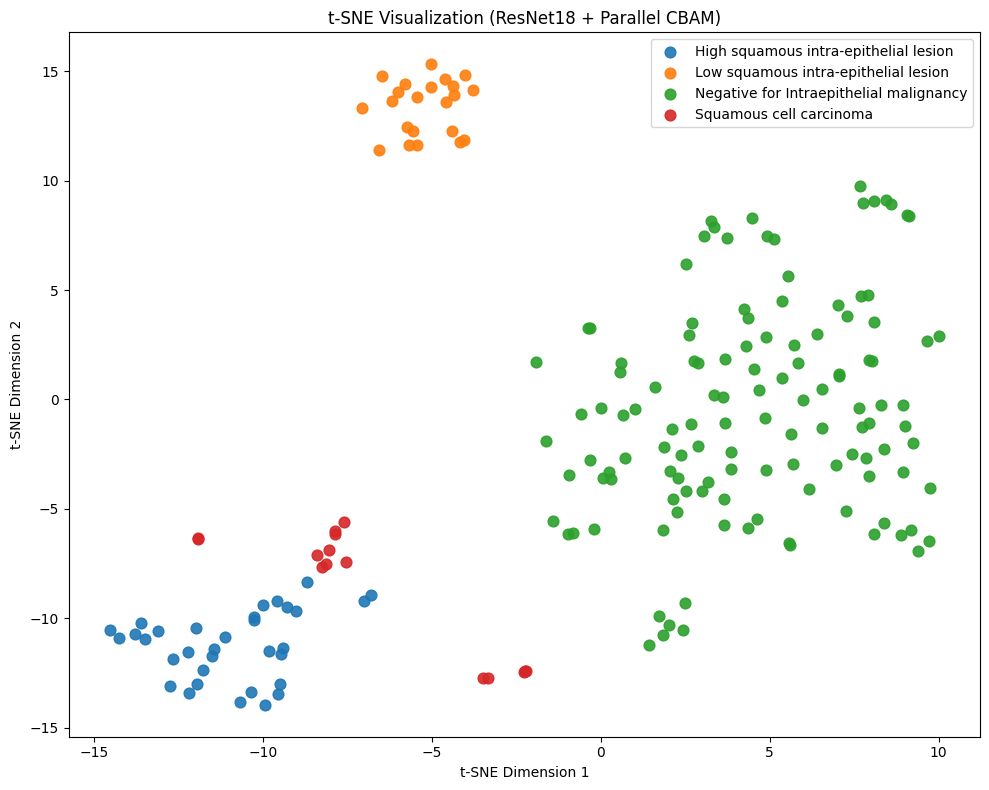

In [99]:
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# =========================
# 1️⃣ RESNET FEATURE EXTRACTION
# =========================

def extract_resnet_features(model, loader, device):

    model.eval()
    features = []
    labels = []

    with torch.no_grad():

        for images, lbls in tqdm(loader, desc="Extracting ResNet Features"):

            images = images.to(device)

            x = model.base_model.conv1(images)
            x = model.base_model.bn1(x)
            x = model.base_model.relu(x)
            x = model.base_model.maxpool(x)

            x = model.base_model.layer1(x)
            x = model.base_model.layer2(x)
            x = model.base_model.layer3(x)
            x = model.base_model.layer4(x)

            x = model.attention(x)

            x = model.avgpool(x)
            x = torch.flatten(x,1)

            features.append(x.cpu().numpy())
            labels.append(lbls.numpy())

    return np.concatenate(features), np.concatenate(labels)


# =========================
# 2️⃣ SWIN FEATURE EXTRACTION
# =========================

def extract_swin_features(model, loader, device):

    model.eval()
    features = []
    labels = []

    with torch.no_grad():

        for images, lbls in tqdm(loader, desc="Extracting Swin Features"):

            images = images.to(device)

            x = model.base_model.features(images)
            x = model.base_model.norm(x)

            x = x.mean(dim=1)

            features.append(x.cpu().numpy())
            labels.append(lbls.numpy())

    return np.concatenate(features), np.concatenate(labels)


# =========================
# 3️⃣ t-SNE COMPUTATION
# =========================

def run_tsne(features):

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        random_state=42
    )

    return tsne.fit_transform(features)


# =========================
# 4️⃣ PLOT FUNCTION
# =========================

def plot_tsne(tsne_features, labels, classes, title, save_name):

    plt.figure(figsize=(10,8))

    for i, class_name in enumerate(classes):

        idx = labels == i

        plt.scatter(
            tsne_features[idx,0],
            tsne_features[idx,1],
            label=class_name,
            alpha=0.7
        )

    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")

    plt.legend()
    plt.tight_layout()

    plt.savefig(save_name, dpi=300)

    plt.show()


# =========================
# 5️⃣ GENERATE RESNET t-SNE
# =========================
cnn_model = ResNet18ParallelCBAM(num_classes=num_classes).to(device)
swin_model = SwinTinyClassifier(num_classes=num_classes).to(device)

cnn_model.load_state_dict(torch.load("best_ResNet18ParallelCBAM_acc.pth", map_location=device))
swin_model.load_state_dict(torch.load("best_SwinTiny_acc.pth", map_location=device))

resnet_features, resnet_labels = extract_resnet_features(cnn_model, test_loader, device)

tsne_resnet = run_tsne(resnet_features)

# plot_tsne(
#     tsne_resnet,
#     resnet_labels,
#     full_dataset.class_names,
#     "t-SNE Visualization (ResNet18 + Parallel CBAM)",
#     "tsne_resnet_cbam.jpg"
# )

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

classes = full_dataset.class_names

for i, class_name in enumerate(classes):

    idx = swin_labels == i

    plt.scatter(
        tsne_resnet[idx,0],
        tsne_resnet[idx,1],
        label=class_name,
        s=60,
        alpha=0.9
    )

plt.title("t-SNE Visualization (ResNet18 + Parallel CBAM)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend()

plt.tight_layout()

plt.savefig("tsne_resnet_cbam.jpg", dpi=300)

plt.show()

# # =========================
# # 6️⃣ GENERATE SWIN t-SNE
# # =========================

# swin_features, swin_labels = extract_swin_features(swin_model, test_loader, device)

# tsne_swin = run_tsne(swin_features)

# plot_tsne(
#     tsne_swin,
#     swin_labels,
#     full_dataset.class_names,
#     "t-SNE Visualization (Swin Tiny)",
#     "tsne_swin.jpg"
# )

In [89]:
def extract_swin_features(model, loader, device):

    model.eval()

    features = []
    labels = []

    with torch.no_grad():

        for images, lbls in tqdm(loader, desc="Extracting Swin Features"):

            images = images.to(device)

            x = model.base_model.features(images)
            x = model.base_model.norm(x)

            # Global average pooling
            x = x.mean(dim=1)

            # Ensure 2D for TSNE
            x = x.view(x.size(0), -1)

            features.append(x.cpu().numpy())
            labels.append(lbls.numpy())

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)

    return features, labels

Extracting Swin Features: 100%|██████████| 7/7 [00:05<00:00,  1.26it/s]


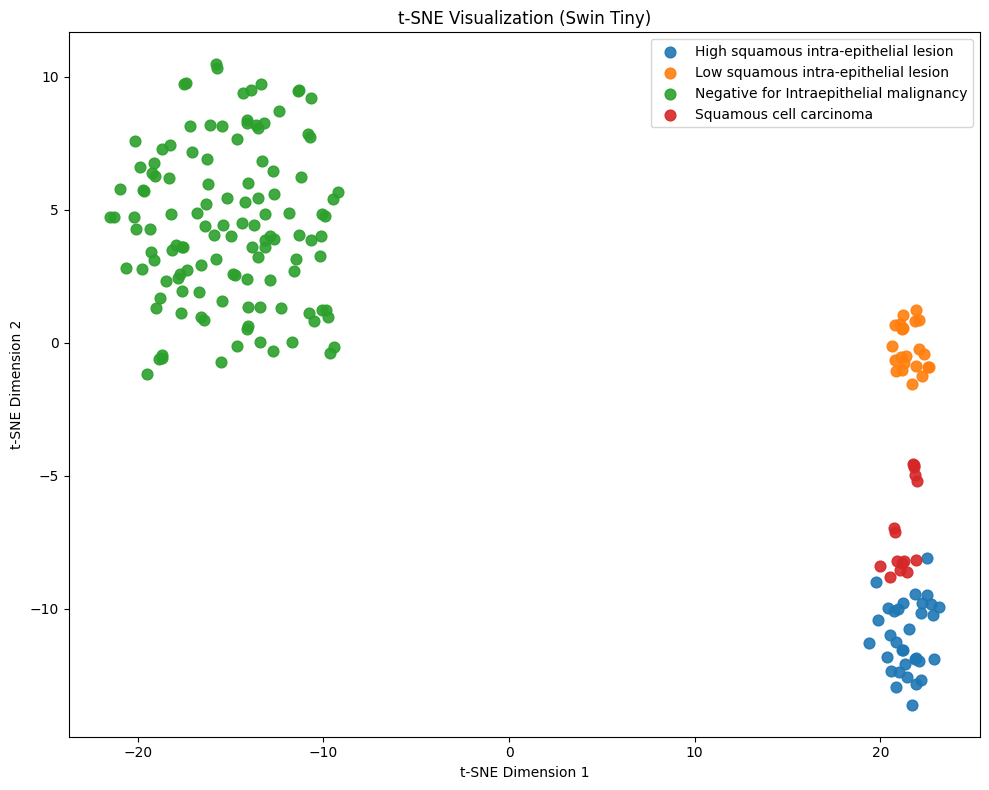

In [95]:
swin_features, swin_labels = extract_swin_features(swin_model, test_loader, device)

tsne_swin = run_tsne(swin_features)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

classes = full_dataset.class_names

for i, class_name in enumerate(classes):

    idx = swin_labels == i

    plt.scatter(
        tsne_swin[idx,0],
        tsne_swin[idx,1],
        label=class_name,
        s=60,
        alpha=0.9
    )

plt.title("t-SNE Visualization (Swin Tiny)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend()

plt.tight_layout()

plt.savefig("tsne_swin.jpg", dpi=300)

plt.show()

In [82]:
# ================= MAJORITY VOTING =================

all_vote_preds = []
all_labels_vote = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Majority Voting"):
        images = images.to(device)

        out_cnn = cnn_model(images)
        out_swin = swin_model(images)

        pred_cnn = torch.argmax(out_cnn, dim=1)
        pred_swin = torch.argmax(out_swin, dim=1)

        for i in range(images.size(0)):
            if pred_cnn[i] == pred_swin[i]:
                final_pred = pred_cnn[i]
            else:
                final_pred = pred_cnn[i]  # tie-break rule

            all_vote_preds.append(final_pred.item())
            all_labels_vote.append(labels[i].item())

vote_acc = accuracy_score(all_labels_vote, all_vote_preds)
print(f"Majority Voting Accuracy: {vote_acc*100:.2f}%")

Majority Voting: 100%|██████████| 7/7 [00:05<00:00,  1.17it/s]

Majority Voting Accuracy: 97.41%


In [91]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

fusion_features = []
fusion_labels = []

with torch.no_grad():
    
    for images, labels in tqdm(test_loader, desc="Extracting Fusion Features"):
        
        images = images.to(device)
        images_flipped = torch.flip(images, dims=[3])

        # CNN probabilities
        p_cnn = (
            F.softmax(cnn_model(images), dim=1) +
            F.softmax(cnn_model(images_flipped), dim=1)
        ) / 2.0

        # Swin probabilities
        p_trans = (
            F.softmax(swin_model(images), dim=1) +
            F.softmax(swin_model(images_flipped), dim=1)
        ) / 2.0

        for i in range(images.size(0)):

            fused_output = compute_sugeno_fusion_99(
                p_cnn[i],
                p_trans[i],
                class_metadata
            )

            fusion_features.append(fused_output.cpu().numpy())
            fusion_labels.append(labels[i].item())

fusion_features = np.array(fusion_features)
fusion_labels = np.array(fusion_labels)

Extracting Fusion Features: 100%|██████████| 7/7 [00:06<00:00,  1.09it/s]


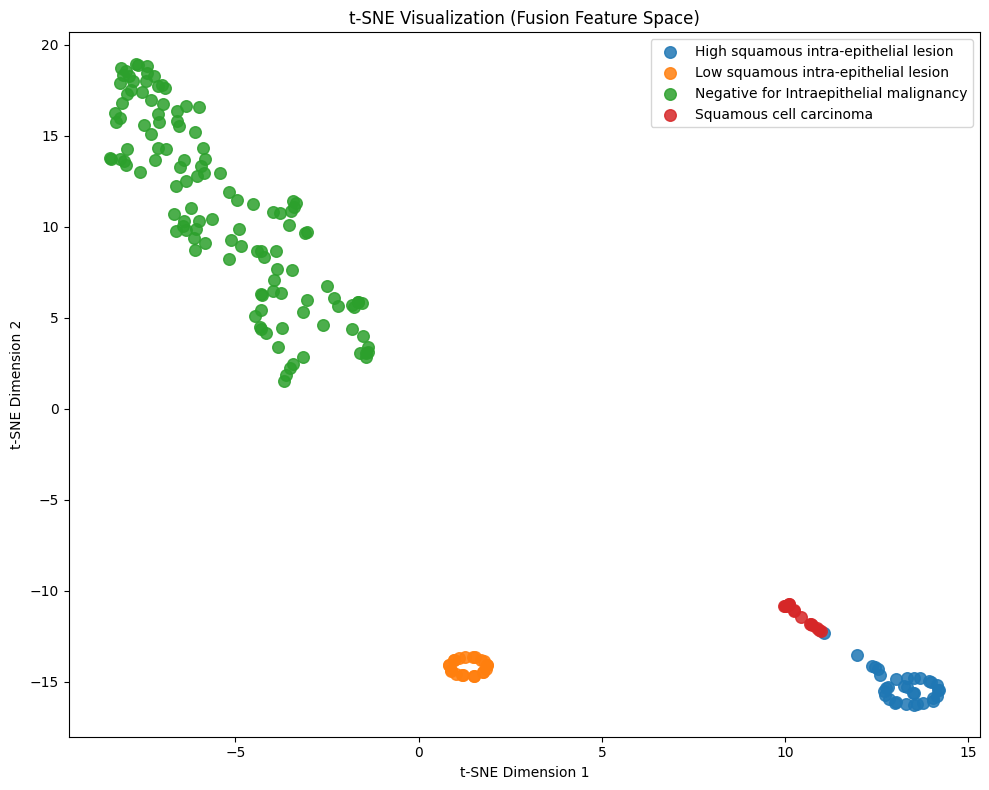

In [97]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

tsne_fusion = tsne.fit_transform(fusion_features)
plt.figure(figsize=(10,8))

classes = full_dataset.class_names

for i, class_name in enumerate(classes):
    
    idx = fusion_labels == i
    
    plt.scatter(
        tsne_fusion[idx,0],
        tsne_fusion[idx,1],
        label=class_name,
        s=70,
        alpha=0.85
    )

plt.title("t-SNE Visualization (Fusion Feature Space)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend()

plt.tight_layout()

plt.savefig("tsne_fusion.jpg", dpi=300)

plt.show()

In [100]:
from IPython.display import FileLink, display

display(FileLink("tsne_resnet_cbam.jpg"))
display(FileLink("tsne_swin.jpg"))
display(FileLink("tsne_fusion.jpg"))

/kaggle/working/tsne_resnet_cbam.jpg

/kaggle/working/tsne_swin.jpg

/kaggle/working/tsne_fusion.jpg